In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_movies.csv
/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_credits.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

## Load Dataset

In [4]:
movies = pd.read_csv('/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_credits.csv')
credits = pd.read_csv('/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_movies.csv')

print("Movies shape:", movies.shape)
print("Credits shape:", credits.shape)
movies.head()

Movies shape: (4803, 4)
Credits shape: (4803, 20)


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


**Basic Exploration**

In [5]:
print("Movies Columns\n", movies.columns.tolist())
print("\nCredits Columns\n", credits.columns.tolist())

print("\nMovies Data Types\n", movies.dtypes)

print("\nMovies Missing Vaules\n", movies.isnull().sum())

Movies Columns
 ['movie_id', 'title', 'cast', 'crew']

Credits Columns
 ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Movies Data Types
 movie_id     int64
title       object
cast        object
crew        object
dtype: object

Movies Missing Vaules
 movie_id    0
title       0
cast        0
crew        0
dtype: int64


****Merge and Clean****

In [6]:
movies = movies.merge(credits, on = 'title')
movies = movies[['movie_id', 'title', 'overview', 'genres', 
                 'keywords', 'cast', 'crew', 'vote_average', 
                 'vote_count', 'popularity', 'release_date']]

movies.dropna(inplace=True)

print("Final shape:", movies.shape)
movies.head()

Final shape: (4805, 11)


,movie_id,title,overview,genres,keywords,cast,crew,vote_average,vote_count,popularity,release_date
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.2,11800,150.437577,2009-12-10
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.9,4500,139.082615,2007-05-19
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.3,4466,107.376788,2015-10-26
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.6,9106,112.312950,2012-07-16
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",6.1,2124,43.926995,2012-03-07


In [7]:
import ast

def safe_extract(obj):
    # If already a list, return as is
    if isinstance(obj, list):
        return obj
    # If it's a string, try to parse it
    try:
        parsed = ast.literal_eval(obj)
        if isinstance(parsed, list):
            # Check if it's a list of dicts or list of strings
            if len(parsed) > 0 and isinstance(parsed[0], dict):
                return [i['name'] for i in parsed]
            else:
                return parsed
    except:
        return []
    return []

def safe_extract_cast(obj, top_n=3):
    if isinstance(obj, list):
        return obj[:top_n]
    try:
        parsed = ast.literal_eval(obj)
        if isinstance(parsed[0], dict):
            return [i['name'] for i in parsed][:top_n]
        return parsed[:top_n]
    except:
        return []

def safe_extract_director(obj):
    try:
        parsed = ast.literal_eval(obj)
        if isinstance(parsed[0], dict):
            for i in parsed:
                if i['job'] == 'Director':
                    return i['name']
    except:
        return ''
    return ''

movies['genres']   = movies['genres'].apply(safe_extract)
movies['keywords'] = movies['keywords'].apply(safe_extract)
movies['cast']     = movies['cast'].apply(safe_extract_cast)
movies['director'] = movies['crew'].apply(safe_extract_director)

print(movies['genres'][0])
print(movies['cast'][0])
print(movies['director'][0])

['Action', 'Adventure', 'Fantasy', 'Science Fiction']
['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver']
James Cameron


## Exploratory Data Analysis 

**Top 10 popular movies**

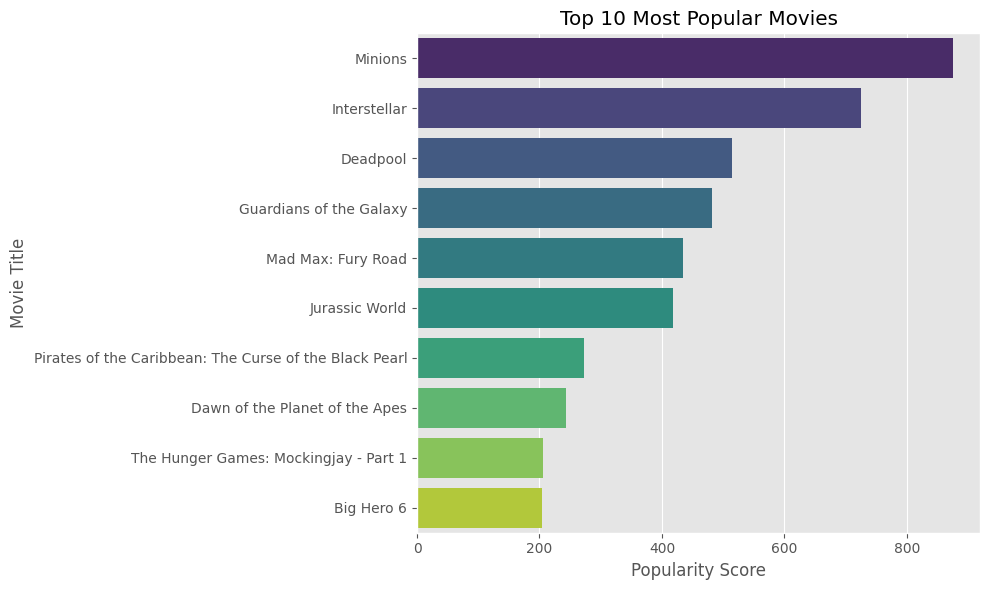

In [8]:
top_popular = movies.nlargest(10, 'popularity')[['title', 'popularity']]

plt.figure(figsize = (10,6))
sns.barplot(data=top_popular, x='popularity', y='title', palette='viridis')
plt.title('Top 10 Most Popular Movies')
plt.xlabel('Popularity Score')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()

**Rating Distribution**

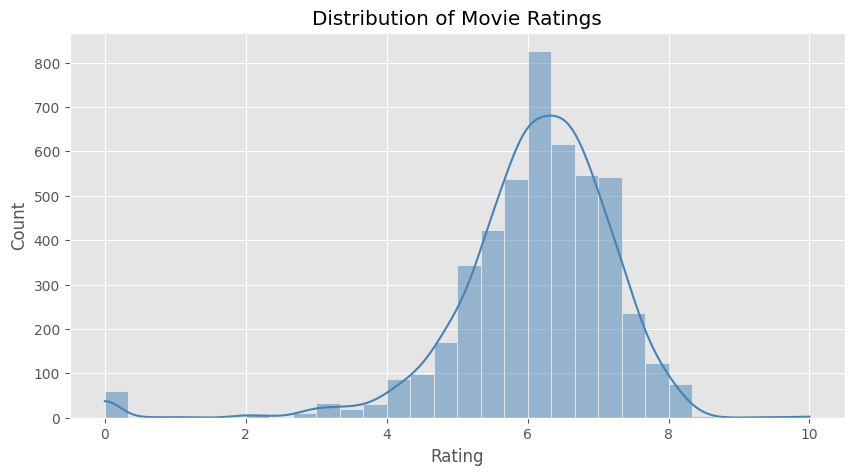

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(movies['vote_average'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

**Top 10 Most Common Genres**

In [10]:
from collections import Counter
all_genres = sum(movies['genres'].tolist(), [])
genre_counts = Counter(all_genres).most_common(10)
genre_df = pd.DataFrame(genre_counts, columns=['Genre', 'Count'])
genre_df

,Genre,Count
0,Drama,2299
1,Comedy,1723
2,Thriller,1275
3,Action,1156
4,Romance,895
5,Adventure,792
6,Crime,697
7,Science Fiction,538
8,Horror,520
9,Family,514


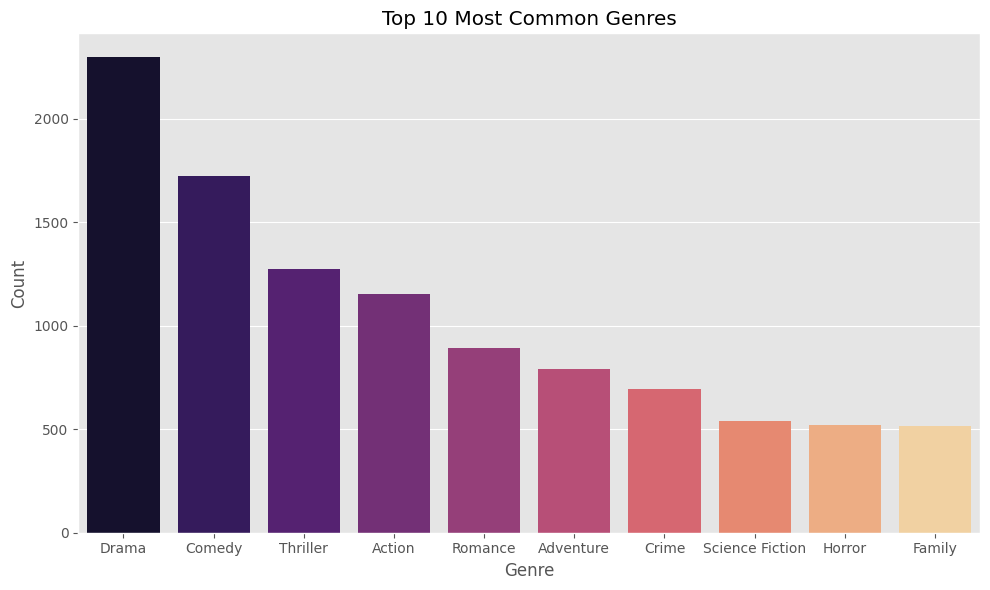

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(data=genre_df, x='Genre', y='Count', palette='magma')
plt.title('Top 10 Most Common Genres')
plt.tight_layout()
plt.show()

**Number of Movies Released per Year**

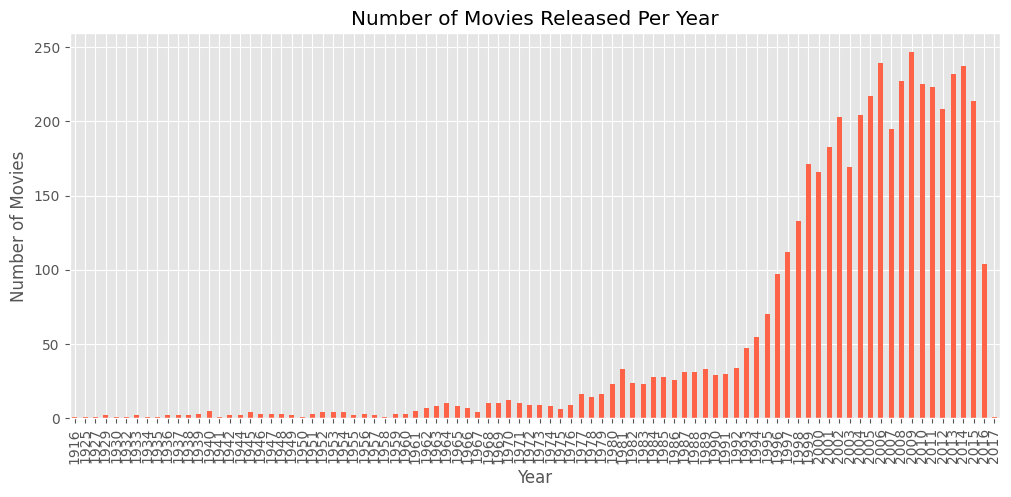

In [12]:
movies['year'] = pd.to_datetime(movies['release_date'], 
                                errors='coerce').dt.year

plt.figure(figsize=(12, 5))
movies['year'].value_counts().sort_index().plot(kind='bar', 
                                                color='tomato')
plt.title('Number of Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

**Correlation Heatmap**

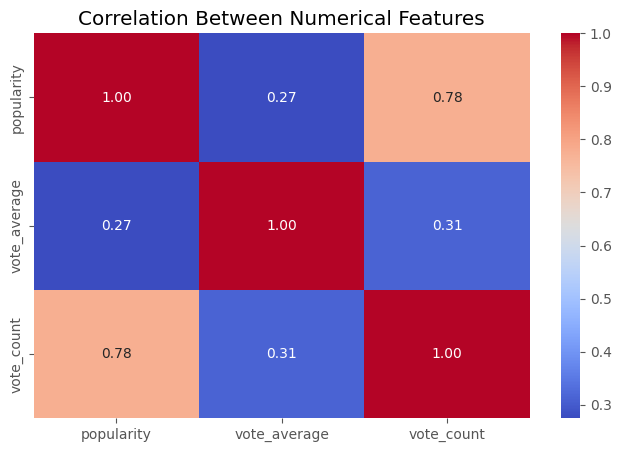

In [13]:
plt.figure(figsize=(8, 5))
corr = movies[['popularity', 'vote_average', 'vote_count']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numerical Features')
plt.show()

## Building Recommendation System 

**Creating Tags Columns**

In [14]:
movies['genres'] = movies['genres'].apply(lambda x: ' '.join(x))
movies['cast'] = movies['cast'].apply(lambda x: ' '.join(x))
movies['keywords'] = movies['keywords'].apply(lambda x: ' '.join(x))

movies['genres'] = movies['genres'].apply(lambda x: x.replace(' ',''))
movies['keywords'] = movies['keywords'].apply(lambda x: x.replace(' ',''))
movies['cast'] = movies['cast'].apply(lambda x: x.replace(' ',''))
movies['director'] = movies['director'].apply(lambda x: x.replace(' ',''))

movies['tags'] = (movies['overview']  + '  '  + 
                  movies['genres']  + '  '  + 
                  movies['cast']  + '  '  + 
                  movies['keywords']  + '  '  + 
                  movies['director'])
df = movies[['movie_id' ,'title', 'tags']].copy()
movies['tags'] = movies['tags'].apply(lambda x: x.lower())

print(df['tags'][0])
df.head()

In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.  ActionAdventureFantasyScienceFiction  SamWorthingtonZoeSaldanaSigourneyWeaver  cultureclashfuturespacewarspacecolonysocietyspacetravelfuturisticromancespacealientribealienplanetcgimarinesoldierbattleloveaffairantiwarpowerrelationsmindandsoul3d  JamesCameron


,movie_id,title,tags
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...
4,49529,John Carter,"John Carter is a war-weary, former military ca..."


**Text Vectorization (TF-IDF)**

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features = 5000, stop_words = 'english')
vectors = tfidf.fit_transform(df['tags']).toarray()

print("Vector Shape: ", vectors.shape)

Vector Shape:  (4805, 5000)


**Cosine Similarity**

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(vectors)

print("Similarity Matrix Shape: ", similarity.shape)
print("Sample Similarity Scores: ", [round(float(x), 2) for x in similarity[0][:10]])

Similarity Matrix Shape:  (4805, 4805)
Sample Similarity Scores:  [1.0, 0.0, 0.0, 0.03, 0.0, 0.03, 0.0, 0.05, 0.0, 0.0]


**Recommendation Function**

In [17]:
from IPython.display import display, Markdown

def recommend(movie_title):
    if movie_title not in df['title'].values:
        display(Markdown(f"Movie **{movie_title}** not found!"))
        print("\n Did you mean one of these?")
        matches = df[df['title'].str.contains(movie_title, case = False)]['title'].values
        print(matches[:5])
        return
        
    movie_index = df[df['title'] == movie_title].index[0]
    distances = similarity[movie_index]

    movie_list = sorted(list(enumerate(distances)), reverse = True, key = lambda x: x[1])[1:6]

    display(Markdown(f"Because you watched **{movie_title}**, you might like: \n"))
    
    for i, (index, score) in enumerate(movie_list, 1):
        print(f"{i}, {df['title'][index]} | "
             f" Similarity : {round(score * 100, 1)}%)")

In [18]:
recommend('Avatar')
recommend('The Dark Knight')
recommend('Toy Story')
recommend('Iron Man')
recommend('Harry Potter')

Because you watched **Avatar**, you might like: 


1, Lone Wolf McQuade |  Similarity : 21.1%)
2, The American |  Similarity : 18.2%)
3, Beowulf |  Similarity : 14.5%)
4, Tears of the Sun |  Similarity : 14.2%)
5, The Adventures of Pluto Nash |  Similarity : 12.5%)


Because you watched **The Dark Knight**, you might like: 


1, The Dark Knight Rises |  Similarity : 38.3%)
2, Batman Forever |  Similarity : 29.4%)
3, Batman Returns |  Similarity : 27.5%)
4, 2:13 |  Similarity : 25.5%)
5, Batman Begins |  Similarity : 23.7%)


Because you watched **Toy Story**, you might like: 


1, Toy Story 3 |  Similarity : 51.7%)
2, Toy Story 2 |  Similarity : 46.4%)
3, The 40 Year Old Virgin |  Similarity : 33.3%)
4, Man on the Moon |  Similarity : 20.2%)
5, Auto Focus |  Similarity : 19.8%)


Because you watched **Iron Man**, you might like: 


1, Iron Man 2 |  Similarity : 33.1%)
2, Iron Man 3 |  Similarity : 24.9%)
3, Avengers: Age of Ultron |  Similarity : 22.7%)
4, Cradle 2 the Grave |  Similarity : 16.9%)
5, Hostage |  Similarity : 16.0%)


Movie **Harry Potter** not found!


 Did you mean one of these?
['Harry Potter and the Half-Blood Prince'
 'Harry Potter and the Order of the Phoenix'
 'Harry Potter and the Goblet of Fire'
 'Harry Potter and the Prisoner of Azkaban'
 "Harry Potter and the Philosopher's Stone"]


**Visualize Recommendation**

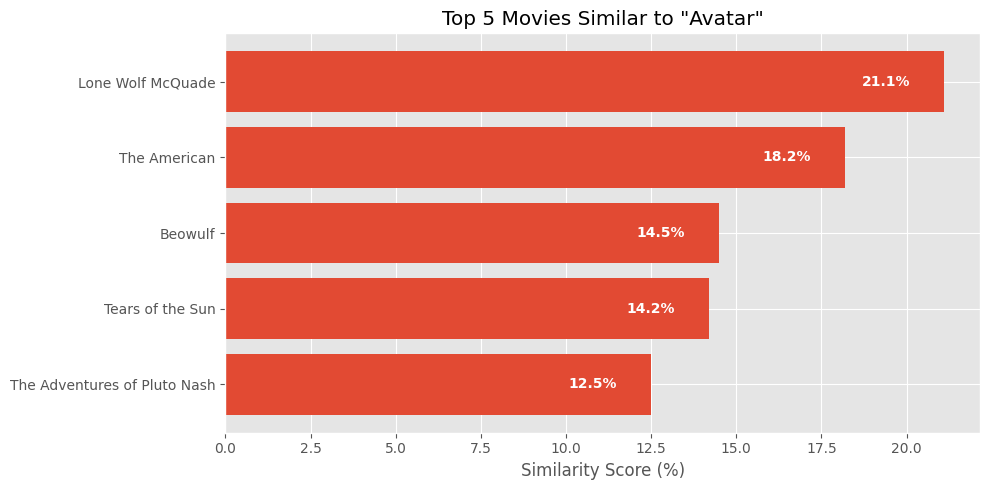

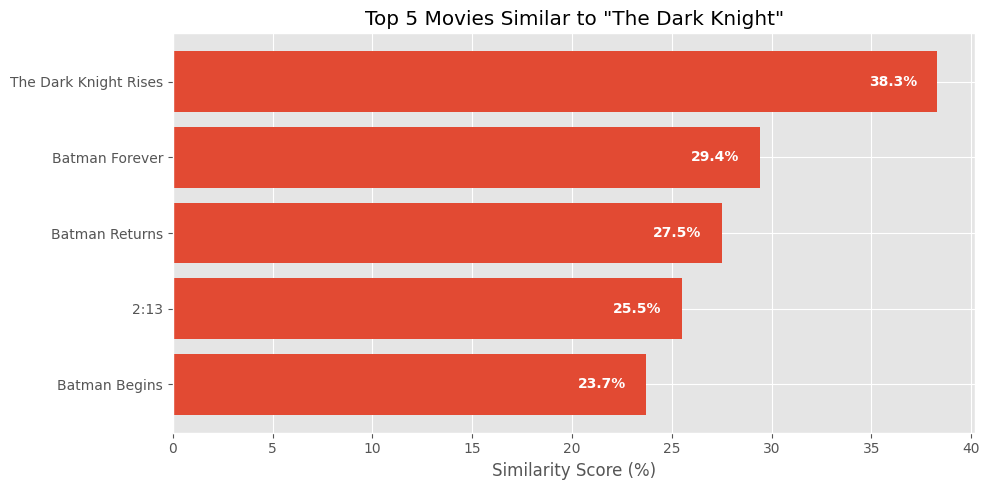

In [19]:
def recommend_with_viz(movie_title):
    if movie_title not in df['title'].values:
        display(Markdown(f"Movie '**{movie_title}**' not found!"))
        return
    
    movie_index = df[df['title'] == movie_title].index[0]
    distances = similarity[movie_index]
    movie_list = sorted(list(enumerate(distances)), 
                        reverse=True, 
                        key=lambda x: x[1])[1:6]
    

    titles = [df['title'][i[0]] for i in movie_list]
    scores = [round(i[1] * 100, 1) for i in movie_list]
    
    plt.figure(figsize=(10, 5))
    bars = plt.barh(titles[::-1], scores[::-1])
    plt.xlabel('Similarity Score (%)')
    plt.title(f'Top 5 Movies Similar to "{movie_title}"')
    
    for bar, score in zip(bars, scores[::-1]):
        plt.text(bar.get_width() - 1, bar.get_y() + bar.get_height()/2,
                f'{score}%', va='center', ha='right', 
                color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

recommend_with_viz('Avatar')
recommend_with_viz('The Dark Knight')

**Save Model**

In [20]:
import pickle

pickle.dump(df, open('movies.pkl', 'wb'))
pickle.dump(similarity, open('similarity.pkl', 'wb'))

print("Model saved successfully :)")

Model saved successfully :)


In [22]:
import pickle
import numpy as np
import pandas as pd


top_similarity = []
for i in range(len(similarity)):
   
    sim_scores = list(enumerate(similarity[i]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:21]  # top 20, skip itself
    top_similarity.append(sim_scores)

df_small = df[['movie_id', 'title']].copy()


pickle.dump(top_similarity, open('similarity_small.pkl', 'wb'))
pickle.dump(df_small, open('movies_small.pkl', 'wb'))

print("Done! Check output sizes")

Done! Check output sizes


In [23]:
import os

print("similarity_small.pkl:", 
      round(os.path.getsize('similarity_small.pkl') / (1024*1024), 2), "MB")

print("movies_small.pkl:", 
      round(os.path.getsize('movies_small.pkl') / (1024*1024), 2), "MB")

similarity_small.pkl: 2.21 MB
movies_small.pkl: 0.16 MB


In [24]:
import pickle
import numpy as np

# Check similarity matrix exists
print("Similarity shape:", similarity.shape)
print("df shape:", df.shape)

# Reduce similarity matrix
top_similarity = []
for i in range(len(similarity)):
    sim_scores = list(enumerate(similarity[i]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:21]
    top_similarity.append(sim_scores)

# Reduce dataframe
df_small = df[['movie_id', 'title']].copy()

# Save with new names
pickle.dump(top_similarity, open('/kaggle/working/similarity_small.pkl', 'wb'))
pickle.dump(df_small, open('/kaggle/working/movies_small.pkl', 'wb'))

# Verify
import os
print("similarity_small.pkl:", 
      round(os.path.getsize('/kaggle/working/similarity_small.pkl') / (1024*1024), 2), "MB")
print("movies_small.pkl:", 
      round(os.path.getsize('/kaggle/working/movies_small.pkl') / (1024*1024), 2), "MB")

Similarity shape: (4805, 4805)
df shape: (4805, 3)
similarity_small.pkl: 2.21 MB
movies_small.pkl: 0.16 MB
